# Feature Engineering — Fake News Detection
## WELFake Dataset
**Name:** Pulindu Pasanjith  
**Goal:** Convert preprocessed text into numerical representations 
suitable for Logistic Regression (TF-IDF) and LSTM (tokenised sequences).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/welFake_cleaned.csv')

print("Shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nSample text:")
print(df['final_text'][0][:200])

Shape: (72095, 2)

Label distribution:
label
1    37067
0    35028
Name: count, dtype: int64

Sample text:
law enforcement high alert following threat cop white blacklivesmatter fyf terrorist video comment expected barack obama member fyf fukyoflag blacklivesmatter movement called lynching hanging white pe


In [3]:
# Drop any remaining null values
df = df.dropna(subset=['final_text'])
df['final_text'] = df['final_text'].astype(str)

print("✅ Nulls handled!")
print("Final shape:", df.shape)

✅ Nulls handled!
Final shape: (72041, 2)


## 1. Train / Test Split
Splitting the dataset into 80% training and 20% testing.
This split is applied once and reused for both ML and DL models
to ensure a fair comparison.

In [4]:
X = df['final_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same class ratio in both splits
)

print("✅ Train/Test Split Complete!")
print(f"Training samples:  {len(X_train):,}")
print(f"Testing samples:   {len(X_test):,}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTesting label distribution:")
print(y_test.value_counts())

✅ Train/Test Split Complete!
Training samples:  57,632
Testing samples:   14,409

Training label distribution:
label
1    29610
0    28022
Name: count, dtype: int64

Testing label distribution:
label
1    7403
0    7006
Name: count, dtype: int64


## 2. TF-IDF Vectorisation (For Logistic Regression)

TF-IDF stands for Term Frequency — Inverse Document Frequency.
It converts each article into a vector of numbers where:
- High values = words that appear often in THIS article but rarely across ALL articles (distinctive words)
- Low values = common words that appear everywhere (less useful)

This representation is ideal for Logistic Regression.

In [5]:
# Create TF-IDF vectoriser
tfidf = TfidfVectorizer(
    max_features=50000,    # keep top 50,000 words
    ngram_range=(1, 2),    # use single words AND pairs of words
    min_df=2,              # ignore words appearing in fewer than 2 articles
    max_df=0.95            # ignore words appearing in more than 95% of articles
)

# Fit on training data ONLY — never fit on test data!
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF Vectorisation Complete!")
print(f"Training matrix shape:  {X_train_tfidf.shape}")
print(f"Testing matrix shape:   {X_test_tfidf.shape}")
print(f"Vocabulary size:        {len(tfidf.vocabulary_):,}")

✅ TF-IDF Vectorisation Complete!
Training matrix shape:  (57632, 50000)
Testing matrix shape:   (14409, 50000)
Vocabulary size:        50,000


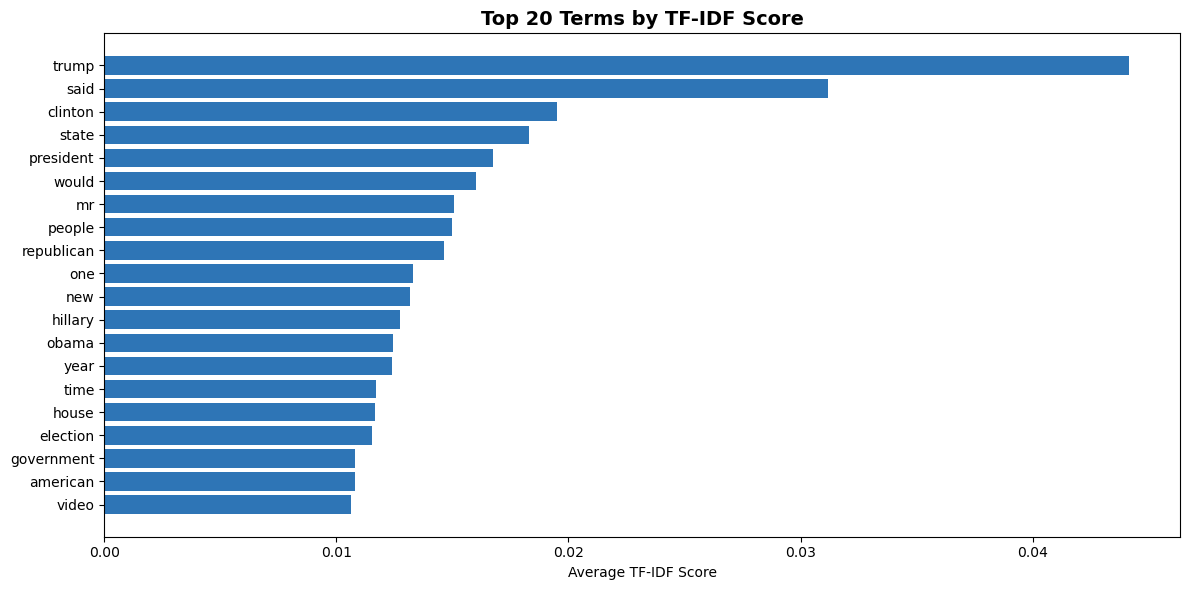

✅ TF-IDF visualisation saved!


In [6]:
# Get feature names and their average TF-IDF scores
feature_names = tfidf.get_feature_names_out()
tfidf_scores = X_train_tfidf.mean(axis=0).A1

# Get top 20 terms
top_indices = tfidf_scores.argsort()[-20:][::-1]
top_terms = [feature_names[i] for i in top_indices]
top_scores = [tfidf_scores[i] for i in top_indices]

plt.figure(figsize=(12, 6))
plt.barh(list(reversed(top_terms)), list(reversed(top_scores)), color='#2E75B6')
plt.title('Top 20 Terms by TF-IDF Score', fontsize=14, fontweight='bold')
plt.xlabel('Average TF-IDF Score')
plt.tight_layout()
plt.savefig('../screenshots/05_tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ TF-IDF visualisation saved!")

In [9]:
import scipy.sparse

# Save the fitted vectoriser — needed later for the web app!
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save train/test splits in SPARSE format — much smaller, no memory error!
scipy.sparse.save_npz('../models/X_train_tfidf.npz', X_train_tfidf)
scipy.sparse.save_npz('../models/X_test_tfidf.npz', X_test_tfidf)

# These are small — fine to save normally
np.save('../models/y_train.npy', y_train.values)
np.save('../models/y_test.npy', y_test.values)

print("✅ TF-IDF vectoriser and splits saved to models/ folder!")
print(f"Training matrix size on disk will be much smaller using sparse format!")

✅ TF-IDF vectoriser and splits saved to models/ folder!
Training matrix size on disk will be much smaller using sparse format!
